In [1]:
# from google.colab import drive
# drive.mount('/content/drive')
# raiz="drive/MyDrive/proyecto_mineria/"
raiz=""

# Cargar datos y generar los conjuntos de entrenamiento y test

In [2]:
import pandas as pd
nombre_csv_logs="presentacion1_resultados.csv"
# file_path = 'data_set_limpio.pkl'
file_path = f'{raiz}datasets_pkl/data_set_limpio_sin_not_for_sale.pkl'

df = pd.read_pickle(file_path)

# Display the loaded DataFrame
print("shape: ",df.shape)
print(df.columns)
df.sample(n=5)


shape:  (186795, 70)
Index(['Nat', 'Division', 'Club', 'Based', 'Preferred Foot', 'Right Foot',
       'Left Foot', 'Position', 'Height', 'Weight', 'Age', 'Wage', 'AT Apps',
       'AT Gls', 'Team', 'Caps', 'Yth Apps', 'Style', 'Rc Injury', 'Best Role',
       'Best Duty', 'Best Pos', 'Acc', 'Aer', 'Agg', 'Agi', 'Ant', 'Bal',
       'Bra', 'Cmd', 'Com', 'Cmp', 'Cnt', 'Cor', 'Cro', 'Dec', 'Det', 'Dri',
       'Ecc', 'Fin', 'Fir', 'Fla', 'Fre', 'Han', 'Hea', 'Jum', 'Kic', 'Ldr',
       'Lon', 'L Th', 'Mar', 'Nat .1', 'OtB', '1v1', 'Pac', 'Pas', 'Pen',
       'Pos', 'Pun', 'Ref', 'TRO', 'Sta', 'Str', 'Tck', 'Tea', 'Tec', 'Thr',
       'Vis', 'Wor', 'transfer_value_estimado'],
      dtype='object')


,Nat,Division,Club,Based,Preferred Foot,Right Foot,Left Foot,Position,Height,Weight,...,TRO,Sta,Str,Tck,Tea,Tec,Thr,Vis,Wor,transfer_value_estimado
152893,ENG,Sky Bet League One,Ipswich,England (Sky Bet League One),Right Only,Very Strong,Weak,"D (R), DM, M (C)",184,75,...,3,14,14,14,16,11,1,9,15,220000
111010,DEN,3F Superliga,AaB,Denmark (3F Superliga),Right,Very Strong,Fairly Strong,"DM, M (C)",182,65,...,3,14,11,11,13,11,2,10,14,550000
36536,ARG,Argentine Premier Division,Aldosivi,Argentina (Premier Division),Right Only,Very Strong,Weak,ST (C),173,62,...,2,9,8,4,7,14,2,7,8,522500
187537,POR,-,-,Portugal,Right,Very Strong,Reasonable,D/WB/M (R),171,67,...,2,12,13,7,6,7,3,6,12,0
101543,RUS,-,-,Russia,Right,Very Strong,Fairly Strong,D (C),189,73,...,3,2,5,7,3,2,2,3,4,0


# Generar conjuntos de entrenamiento y test

In [3]:
import pandas as pd
import json
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error

def log_results(model, method_name, X_train, y_train, X_test, y_test,
                filepath=f"{raiz}{nombre_csv_logs}.csv"):
    params_dict = model.get_params()
    for k, v in params_dict.items():
        try:
            json.dumps(v)
        except TypeError:
            params_dict[k] = str(v)
    params = json.dumps(params_dict)

    y_pred = model.predict(X_test)

    r2_train = model.score(X_train, y_train)
    r2_test  = model.score(X_test,  y_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    row = {
        "method":          method_name,
        "hyperparameters": json.dumps(params),
        "r2_train":        r2_train,
        "r2_test":         r2_test,
        "mae":             mae,
        "rmse":            rmse
    }

    residuals = y_test - y_pred
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(residuals, bins=50, kde=True, color="blue")
    plt.axvline(x=0, color='red', linestyle='--')
    plt.title("Residuals Distribution")
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],
             color='red', linestyle='--')
    plt.title("Regression Fit: Actual vs Predicted")
    plt.xlabel("Actual Transfer Values")
    plt.ylabel("Predicted Transfer Values")

    plt.suptitle(method_name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"  R² train : {r2_train:.4f}")
    print(f"  R² test  : {r2_test:.4f}")
    print(f"  MAE      : {mae:.2f}")
    print(f"  RMSE     : {rmse:.2f}")

    try:
        df_log = pd.read_csv(filepath)
        df_log = pd.concat([df_log, pd.DataFrame([row])], ignore_index=True)
    except FileNotFoundError:
        df_log = pd.DataFrame([row])

    df_log.to_csv(filepath, index=False)

# Generar conjuntos de entrenamiento y test

In [4]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [5]:
import clustering as cl

kmeans_model_club = cl.fit_kmeans(train_df, columna="Club")
kmeans_model_nat = cl.fit_kmeans(train_df, columna="Nat")
kmeans_model_division = cl.fit_kmeans(train_df, columna="Division")


train_df = cl.apply_kmeans(train_df, kmeans_model_club)
train_df = cl.apply_kmeans(train_df, kmeans_model_nat)
train_df = cl.apply_kmeans(train_df, kmeans_model_division)

test_df = cl.apply_kmeans(test_df, kmeans_model_club)
test_df = cl.apply_kmeans(test_df, kmeans_model_nat)
test_df = cl.apply_kmeans(test_df, kmeans_model_division)



# Considerar solo las más importantes
Si previamente ejecutamos el algoritmo y ya tenemos el archivo

In [6]:
import json
target="transfer_value_estimado"
with open("importantes.json", "r") as f:
    cols_to_keep = json.load(f)
    
cols_to_keep.append(target)
train_df=train_df[cols_to_keep]
test_df=test_df[cols_to_keep]

In [7]:
drop_columns=["Club","Nat","Division",target]
X_train = train_df.drop(columns=drop_columns)
y_train = train_df[target]

X_test = test_df.drop(columns=drop_columns)
y_test = test_df[target]

In [8]:
X_train.columns

Index(['Wage', 'Age', 'Based', 'Acc', 'Caps', 'Pac', 'Club_cluster', 'Cmp',
       'Dec', 'Str', 'Team', 'Bal', 'Dri', 'AT Gls', 'Tec', 'Tea', 'Mar',
       'Position', 'Height', 'AT Apps', 'Pen', 'Right Foot', 'L Th', 'Wor',
       'Han', 'Ant', 'Cor', 'Vis', 'Com', 'Preferred Foot', 'Yth Apps', 'Cro',
       'Fir', 'Best Pos', 'Ref', 'Jum', 'Aer', 'Pos', 'Nat_cluster',
       'Division_cluster'],
      dtype='object')

## One Hot para las features categóricas

In [9]:
# import numpy as np
# # categorical_cols=["Nat_cluster","Division_cluster","Club_cluster","Preferred Foot","Right Foot","Left Foot","Best Pos","Best Duty","Style","Best Role","Rc Injury"]
# categorical_cols=["Nat_cluster","Division_cluster","Best Duty","Style"]
# X_train = pd.get_dummies(X_train, columns=categorical_cols)
# X_test  = pd.get_dummies(X_test, columns=categorical_cols)

# X_train, X_test = X_train.align(X_test, join='left', axis=1,fill_value=0)

In [10]:
# X_train = X_train.select_dtypes(include=[np.number,np.bool_])
# X_test = X_test.select_dtypes(include=[np.number,np.bool_])

In [11]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X_train = pd.DataFrame(
#     scaler.fit_transform(X_train),
#     columns=X_train.columns,
#     index=X_train.index
# )

# X_test = pd.DataFrame(
#     scaler.transform(X_test),
#     columns=X_test.columns,
#     index=X_test.index
# )

In [12]:
print(X_train.shape)
print(X_test.shape)

(149436, 40)
(37359, 40)


# Entrenamiento

In [13]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingRegressor

# 1. Identify categorical columns
cat_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()

print(f"Categorical columns: {cat_cols}")

# 2. Copy datasets
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# 3. Encode all categorical columns
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train_encoded[cat_cols] = encoder.fit_transform(
    X_train[cat_cols]
)

X_test_encoded[cat_cols] = encoder.transform(
    X_test[cat_cols]
)

# 4. Train model
model = HistGradientBoostingRegressor()

# 

Categorical columns: ['Based', 'Team', 'Position', 'Right Foot', 'Preferred Foot', 'Best Pos']


# Entrenamiento y Evaluación

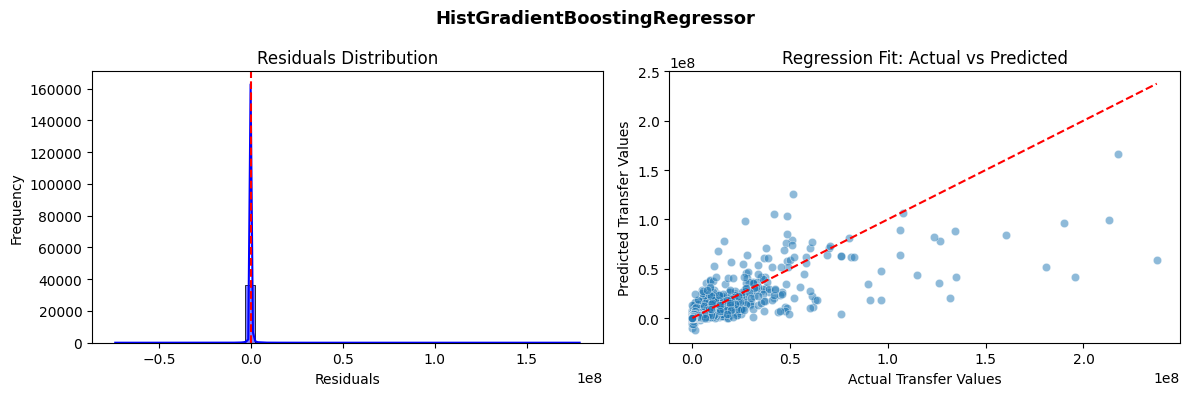

  R² train : 0.8368
  R² test  : 0.6290
  MAE      : 334765.80
  RMSE     : 2727249.10


In [14]:
model.fit(X_train_encoded, y_train)
# model.fit(X_train_encoded, y_train)

# # 5. Predict
preds = model.predict(X_test_encoded)
log_results(model,"HistGradientBoostingRegressor",X_train_encoded,y_train,X_test_encoded,y_test,filepath=nombre_csv_logs)

In [15]:
preds = model.predict(X_test_encoded)
print("saco ",model.score(X_test_encoded,y_test))
preds

saco  0.6290439348898058


array([313592.24226762, -20476.56731623,  19301.32646818, ...,
        33984.53647314,   7430.74813052,  34534.81011022], shape=(37359,))

# Feature importance

In [16]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    model,          # trained HistGradientBoostingRegressor
    X_test_encoded,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

importance_df = pd.DataFrame({
    "feature": X_test_encoded.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
})

importance_df = importance_df.sort_values(
    "importance_mean",
    ascending=False
)

print(importance_df)

             feature  importance_mean  importance_std
0               Wage    386855.465299     3953.243341
1                Age    225618.208216     5279.562415
2              Based     20809.290265     2316.694821
25               Ant      7908.317594      680.928209
5                Pac      6095.521733     1093.874227
3                Acc      5935.130688     1486.978785
6       Club_cluster      5706.496057      175.299619
8                Dec      5535.102595     1488.937570
4               Caps      5216.684769      359.329183
37               Pos      5057.666883      762.411366
7                Cmp      2882.017376      475.041712
23               Wor      2784.107663     1093.438948
9                Str      2762.903371      731.436158
24               Han      2645.328486      396.545844
11               Bal      2218.692482      283.434625
32               Fir      2035.715924      297.145862
10              Team      1877.135965     1008.079664
34               Ref      18

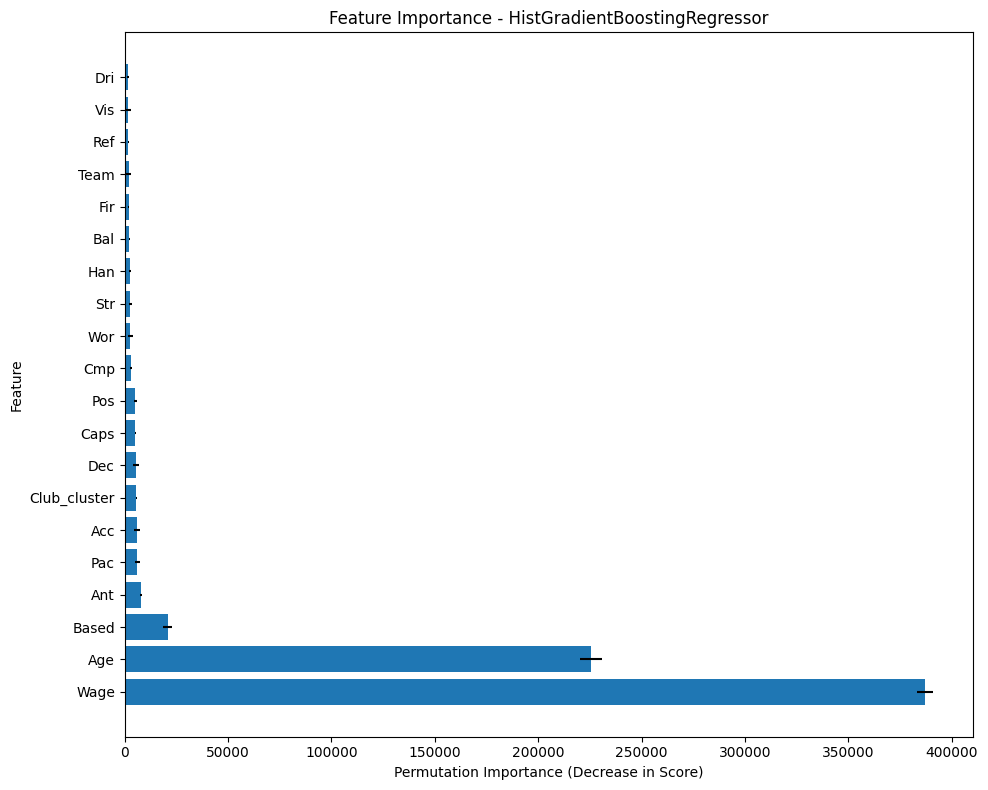

In [17]:
import matplotlib.pyplot as plt

# Optional: keep only top N features
top_n = 20
plot_df = importance_df.head(top_n)

# Create figure
plt.figure(figsize=(10, 8))

# Horizontal bar plot
plt.barh(
    plot_df["feature"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_std"]
)

# Labels and title
plt.xlabel("Permutation Importance (Decrease in Score)")
plt.ylabel("Feature")
plt.title("Feature Importance - HistGradientBoostingRegressor")

# Highest importance at top
# plt.gca().invert_yaxis()

# Better spacing
plt.tight_layout()

# Show plot
plt.show()

In [18]:
import pandas as pd
visualizar_todo=True
if visualizar_todo:
    # Show all rows
    pd.set_option('display.max_rows', None)

    # Show all columns
    pd.set_option('display.max_columns', None)

    # Show full content of each cell (prevent text truncation)
    pd.set_option('display.max_colwidth', None)

print(importance_df)

             feature  importance_mean  importance_std
0               Wage    386855.465299     3953.243341
1                Age    225618.208216     5279.562415
2              Based     20809.290265     2316.694821
25               Ant      7908.317594      680.928209
5                Pac      6095.521733     1093.874227
3                Acc      5935.130688     1486.978785
6       Club_cluster      5706.496057      175.299619
8                Dec      5535.102595     1488.937570
4               Caps      5216.684769      359.329183
37               Pos      5057.666883      762.411366
7                Cmp      2882.017376      475.041712
23               Wor      2784.107663     1093.438948
9                Str      2762.903371      731.436158
24               Han      2645.328486      396.545844
11               Bal      2218.692482      283.434625
32               Fir      2035.715924      297.145862
10              Team      1877.135965     1008.079664
34               Ref      18

In [19]:
genera_json=False
if genera_json:
    importantes=importance_df.loc[importance_df["importance_mean"] >= 0, "feature"].unique()
    importantes=importantes.tolist()
    import json

    with open("importantes.json", "w") as f:
        json.dump(importantes, f)


# Grid search

In [20]:
# from sklearn.model_selection import GridSearchCV
# param_grid = {
#     'regressor__max_iter': [100, 200],
#     'regressor__learning_rate': [0.01, 0.1],
#     'regressor__max_leaf_nodes': [31, 63],
#     # You can even tune the preprocessor!
#     'prep__high_card__smooth': ['auto', 1.0] 
# }
# gbr_cv = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, scoring='neg_mean_squared_error')
# gbr_cv.fit(X_train, y_train)

## Evaluación

In [ ]:
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# y_pred = gbr_cv.predict(X_test)
# mae=mean_absolute_error(y_test, y_pred)
# mse=mean_squared_error(y_test, y_pred)
# r2s=r2_score(y_test, y_pred)

# print("Best parameters ",gbr_cv.best_params_)
# print("mean_absolute_error: ",mae)
# print("mean_squared_error: ",mse
# print("r2_score: ",r2s)